In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive')

['Getting started.pdf',
 'MS Office 2019 Puls.rar',
 'Gmail Password.txt',
 'PORtFoli',
 'PORtFoli.zip',
 'Muhammad Farhan (2).pdf',
 'Muhammad Farhan (1).pdf',
 'WhatsApp Image 2026-05-12 at 4.50.14 PM.jpeg',
 'Classroom',
 'Muhammad Farhan.pdf',
 'Muhammad-Farhan (1).pdf',
 'Muhammad-Farhan.pdf',
 'Colab Notebooks',
 'Muhammad Farhan_CV.pdf',
 'Gun_noGun.zip',
 'No_gun data.zip',
 'Animal_Classificatio.zip']

In [3]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/Animal_Classificatio.zip', 'r') as zip_ref:
  zip_ref.extractall('/content/Animal_Classificatio')

In [4]:
os.listdir('/content/Animal_Classificatio/animals_dataset/')

['validation', 'train', 'test']

In [5]:
trian_path =  '/content/Animal_Classificatio/animals_dataset/train'

for animal in os.listdir(trian_path):
  path = os.path.join(trian_path,animal)
  print(f'{animal} : {len(os.listdir(path))}')

deep : 87
cat : 91
lion : 89
cow : 86
dog : 111


In [6]:
validation_path =  '/content/Animal_Classificatio/animals_dataset/validation'

for animal in os.listdir(validation_path):
  path = os.path.join(validation_path,animal)
  print(f'{animal} : {len(os.listdir(path))}')

deep : 17
cat : 17
lion : 17
cow : 15
dog : 17


In [7]:
test_path =  '/content/Animal_Classificatio/animals_dataset/test'

for animal in os.listdir(test_path):
  path = os.path.join(test_path,animal)
  print(f'{animal} : {len(os.listdir(path))}')

deep : 16
cat : 17
lion : 17
cow : 16
dog : 16


In [8]:
for split in ['train', 'validation', 'test']:
    print(f"--- {split} ---")
    split_path = f'/content/Animal_Classificatio/animals_dataset/{split}'
    for animal in os.listdir(split_path):
        path = os.path.join(split_path, animal)
        print(animal, ":", len(os.listdir(path)))

--- train ---
deep : 87
cat : 91
lion : 89
cow : 86
dog : 111
--- validation ---
deep : 17
cat : 17
lion : 17
cow : 15
dog : 17
--- test ---
deep : 16
cat : 17
lion : 17
cow : 16
dog : 16


In [9]:
class_names = ['dog','lion','cow','cat','deep']
class_to_label = {name: idx for idx, name in enumerate(class_names)}
print(class_to_label)

{'dog': 0, 'lion': 1, 'cow': 2, 'cat': 3, 'deep': 4}


In [10]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

In [11]:
def load_images_from_folder(folder_path, class_names, img_size=128):
    X = []
    y = []
    for class_name in class_names:
        class_path = os.path.join(folder_path, class_name)
        label = class_to_label[class_name]
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            img = load_img(img_path, target_size=(img_size, img_size))
            img_array = img_to_array(img)
            X.append(img_array)
            y.append(label)
    return np.array(X), np.array(y)

In [12]:
X_train, y_train = load_images_from_folder('/content/Animal_Classificatio/animals_dataset/train/', class_names)
X_val, y_val = load_images_from_folder('/content/Animal_Classificatio/animals_dataset/validation/', class_names)
X_test, y_test = load_images_from_folder('/content/Animal_Classificatio/animals_dataset/test/', class_names)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (464, 128, 128, 3) (464,)
Validation: (83, 128, 128, 3) (83,)
Test: (82, 128, 128, 3) (82,)


In [13]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

In [14]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=5)
y_val_cat = to_categorical(y_val, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(y_train_cat.shape)
print(y_train_cat[0])

(464, 5)
[1. 0. 0. 0. 0.]


In [15]:
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [16]:
model = keras.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_data=(X_val, y_val_cat))

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - accuracy: 0.2220 - loss: 1.6324 - val_accuracy: 0.2048 - val_loss: 1.6014
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2586 - loss: 1.5838 - val_accuracy: 0.2651 - val_loss: 1.5884
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3168 - loss: 1.5502 - val_accuracy: 0.3253 - val_loss: 1.5191
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4030 - loss: 1.4464 - val_accuracy: 0.5301 - val_loss: 1.3581
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4418 - loss: 1.3581 - val_accuracy: 0.5301 - val_loss: 1.3001
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5345 - loss: 1.1922 - val_accuracy: 0.4458 - val_loss: 1.3307
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6034 - loss: 1.0693 - val_accuracy: 0.4940 - val_loss: 1.3454
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6789 - loss: 0.8757 - val_accuracy: 0.4699 -

In [19]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step
Accuracy: 0.43902439024390244

Classification Report:
               precision    recall  f1-score   support

         dog       0.33      0.31      0.32        16
        lion       0.50      0.47      0.48        17
         cow       0.45      0.56      0.50        16
         cat       0.27      0.18      0.21        17
        deep       0.55      0.69      0.61        16

    accuracy                           0.44        82
   macro avg       0.42      0.44      0.43        82
weighted avg       0.42      0.44      0.42        82

Confusion Matrix:
 [[ 5  0  5  3  3]
 [ 2  8  2  2  3]
 [ 2  0  9  2  3]
 [ 5  6  3  3  0]
 [ 1  2  1  1 11]]


In [20]:
model2 = keras.Sequential([
    Conv2D(32, (3,3), activation='tanh', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='tanh'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='tanh'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='tanh'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model2.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_data=(X_val, y_val_cat))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 399ms/step - accuracy: 0.2349 - loss: 1.6683 - val_accuracy: 0.2048 - val_loss: 1.6263
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2974 - loss: 1.5524 - val_accuracy: 0.3373 - val_loss: 1.5389
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3966 - loss: 1.4944 - val_accuracy: 0.2651 - val_loss: 1.5209
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4116 - loss: 1.4505 - val_accuracy: 0.4458 - val_loss: 1.4638
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4203 - loss: 1.4076 - val_accuracy: 0.3735 - val_loss: 1.4498
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4353 - loss: 1.3663 - val_accuracy: 0.3976 - val_loss: 1.4180
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5108 - loss: 1.3082 - val_accuracy: 0.4458 - val_loss: 1.4176
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4871 - loss: 1.2974 - val_accuracy: 0.3976 - 

In [21]:
y_pred_prob = model2.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step
Accuracy: 0.4268292682926829

Classification Report:
               precision    recall  f1-score   support

         dog       0.27      0.44      0.33        16
        lion       0.67      0.47      0.55        17
         cow       0.46      0.69      0.55        16
         cat       0.56      0.29      0.38        17
        deep       0.36      0.25      0.30        16

    accuracy                           0.43        82
   macro avg       0.46      0.43      0.42        82
weighted avg       0.47      0.43      0.42        82

Confusion Matrix:
 [[ 7  0  5  2  2]
 [ 4  8  2  0  3]
 [ 3  0 11  0  2]
 [ 6  2  4  5  0]
 [ 6  2  2  2  4]]


In [22]:
model3 = keras.Sequential([
    Conv2D(32, (3,3), activation='sigmoid', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='sigmoid'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='sigmoid'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='sigmoid'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model3.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history3 = model3.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_data=(X_val, y_val_cat))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 442ms/step - accuracy: 0.2026 - loss: 2.6468 - val_accuracy: 0.1807 - val_loss: 2.3022
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1746 - loss: 2.2844 - val_accuracy: 0.1807 - val_loss: 2.0654
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2004 - loss: 2.0876 - val_accuracy: 0.1807 - val_loss: 1.8852
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1961 - loss: 2.0402 - val_accuracy: 0.2048 - val_loss: 1.7738
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.2069 - loss: 1.8819 - val_accuracy: 0.2048 - val_loss: 1.6750
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2004 - loss: 1.7922 - val_accuracy: 0.2048 - val_loss: 1.6356
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1853 - loss: 1.7869 - val_accuracy: 0.2048 - val_loss: 1.6173
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2069 - loss: 1.7439 - val_accuracy: 0.2048 - 

In [23]:
y_pred_prob = model2.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 0.4268292682926829

Classification Report:
               precision    recall  f1-score   support

         dog       0.27      0.44      0.33        16
        lion       0.67      0.47      0.55        17
         cow       0.46      0.69      0.55        16
         cat       0.56      0.29      0.38        17
        deep       0.36      0.25      0.30        16

    accuracy                           0.43        82
   macro avg       0.46      0.43      0.42        82
weighted avg       0.47      0.43      0.42        82

Confusion Matrix:
 [[ 7  0  5  2  2]
 [ 4  8  2  0  3]
 [ 3  0 11  0  2]
 [ 6  2  4  5  0]
 [ 6  2  2  2  4]]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


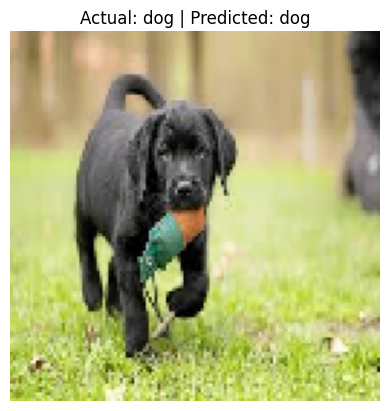

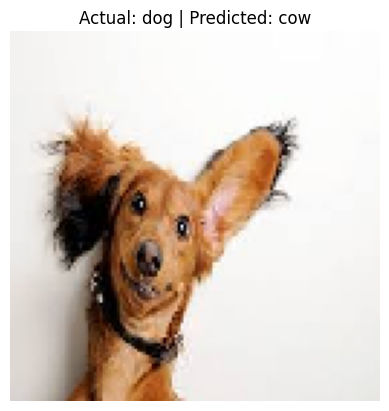

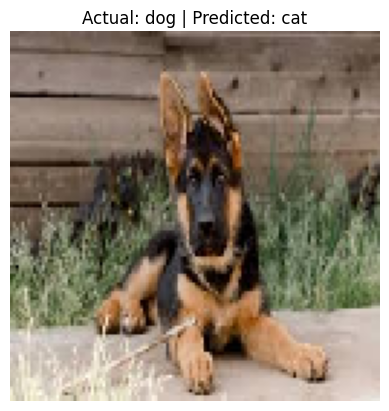

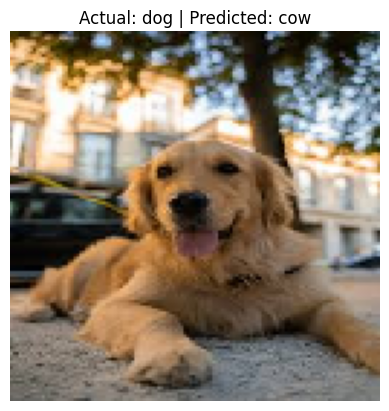

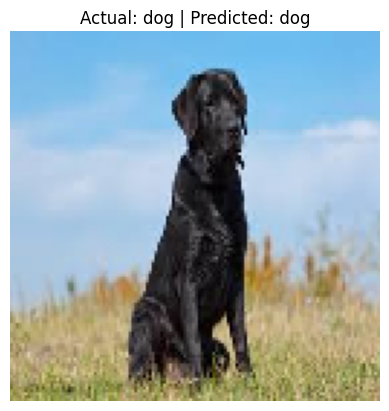

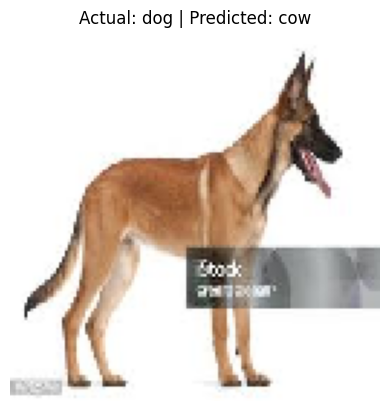

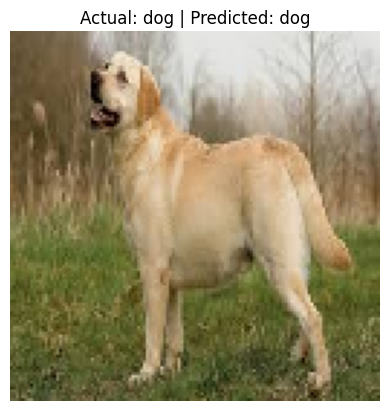

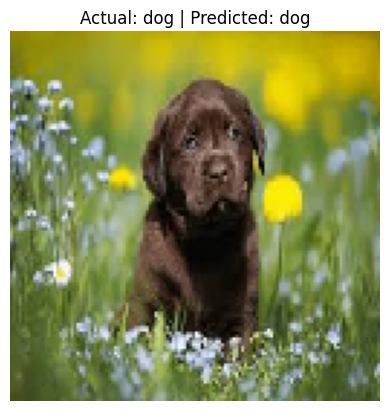

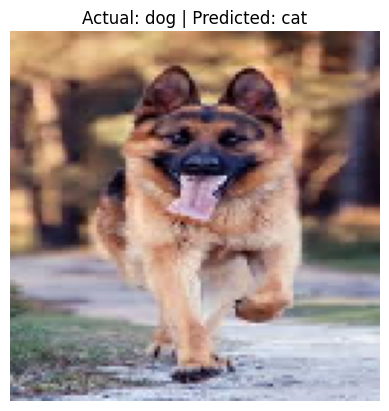

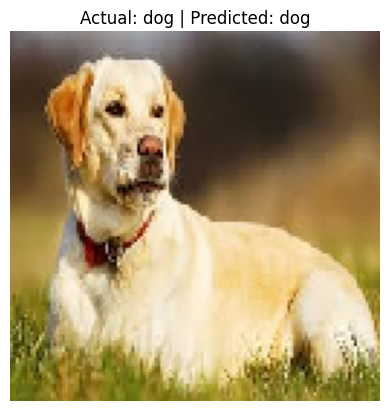

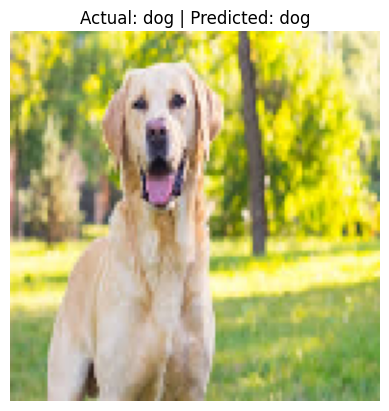

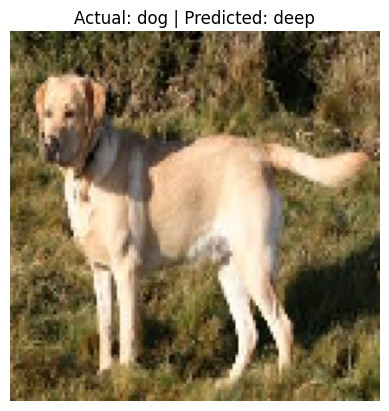

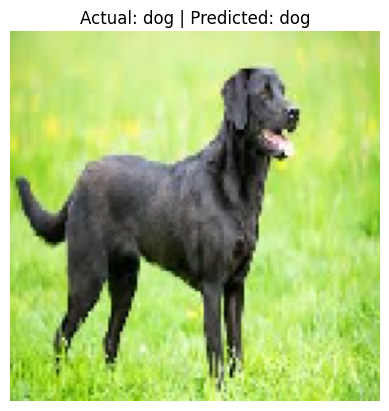

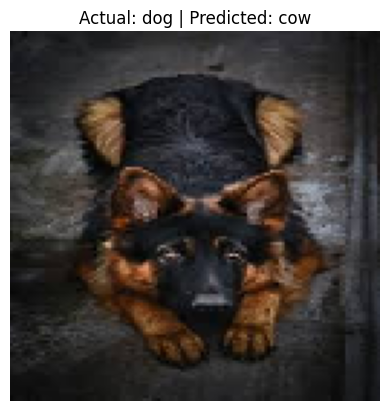

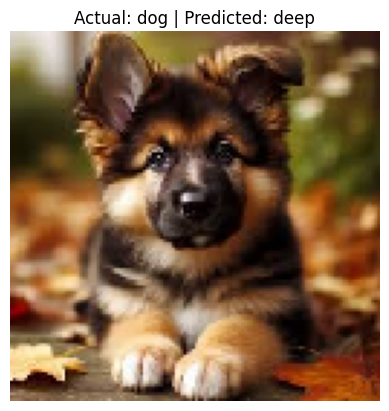

In [25]:
y_pred_prob2 = model2.predict(X_test)
y_pred2 = np.argmax(y_pred_prob2, axis=1)

import matplotlib.pyplot as plt

for i in range(15):
    plt.imshow(X_test[i])
    actual_name = class_names[y_test_labels[i]]
    pred_name = class_names[y_pred2[i]]
    plt.title(f"Actual: {actual_name} | Predicted: {pred_name}")
    plt.axis('off')
    plt.show()

# **Conclusion**
Is assignment mein humne CNN (Convolutional Neural Network) ka use karte hue 5 animal species (dog, lion, cow, cat, deer) ko classify kiya. Dataset already train/validation/test mein pre-split tha, total 629 images ke saath — jo deep learning ke lehaz se kaafi chhota dataset tha.

Teen alag ANN configurations train ki gayin: Model 1 (ReLU + Adam), Model 2 (Tanh + SGD), aur Model 3 (Sigmoid + RMSprop), sab mein 3 Convolutional layers, Dropout regularization, aur softmax output layer (5 classes ke liye) use hui.

Teeno models ne significant overfitting dikhayi — training accuracy 90%+ tak pohanchi lekin validation/test accuracy 43-48% ke darmiyan rahi. Ye chhote training dataset (sirf ~464 images, 5 classes mein baante hue — har class mein sirf ~90 images) ki wajah se hua, jo is tarah ke deep CNN architecture (3.3 million parameters) ke liye kaafi kam hai.

Model 2 (Tanh + SGD) sabse behtar raha, test accuracy 47.6% aur macro F1-score 0.47 ke sath, Model 1 aur 3 (dono 42.7%) se thoda behtar. Confusion matrix dikhati hai ke lion aur cow classes sabse acchi tarah detect hui, jab ke dog aur cat doosri classes ke sath zyada confuse hui.

Overall performance improve karne ke liye, future mein zyada training data, data augmentation (existing images ko rotate/flip/zoom kar ke artificially barhana), aur transfer learning (pehle se trained models jaise MobileNet/VGG use karna) jaise techniques madadgar ho sakti hain, khaas kar jab dataset itna chhota ho.

Ye copy kar ke notebook mein daal dein. Ab dono assignments ka core kaam mukammal ho chuka hai — bas notebook run kar ke GitHub par upload karna baaki hai, jaisa pehli assignment mein kiya tha.